# Customer Segmentation Analysis (RFM + K-Means)

**Objective:** Segment an e-commerce customer base into distinct groups based on purchasing behaviour, so marketing can be targeted per segment.

**Dataset:** *Online Retail* (UCI Machine Learning Repository) — ~542k transactions from a UK-based online gift retailer, Dec 2010 – Dec 2011.

**Stack:** Python, pandas, scikit-learn (KMeans), matplotlib, seaborn.

**Contents**
1. Load & inspect data
2. Data cleaning (missing values, cancellations, invalid rows)
3. Descriptive statistics (avg purchase value, frequency, customer lifetime value)
4. Feature engineering — RFM
5. Standardisation
6. Elbow method & silhouette to pick K
7. K-Means clustering
8. Cluster visualisation (scatter plots)
9. Cluster profiling
10. Customers per cluster (bar chart)
11. Insights & marketing recommendations


In [1]:
import os, zipfile, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
print("Libraries loaded")

Libraries loaded


## 1. Load the dataset
The notebook uses a local copy of `Online Retail.xlsx` if present, otherwise downloads it from the UCI repository.

In [2]:
URL = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
XLSX = "Online Retail.xlsx"

if not os.path.exists(XLSX):
    print("Downloading dataset from UCI ...")
    urllib.request.urlretrieve(URL, "online_retail.zip")
    with zipfile.ZipFile("online_retail.zip") as z:
        z.extractall(".")

df = pd.read_excel(XLSX)
print("Shape:", df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [4]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDate range:", df.InvoiceDate.min(), "->", df.InvoiceDate.max())
print("Unique customers:", df.CustomerID.nunique())
print("Unique invoices:", df.InvoiceNo.nunique())
print("Countries:", df.Country.nunique())
df.describe()

Missing values per column:


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64



Duplicate rows: 5268

Date range: 2010-12-01 08:26:00 -> 2011-12-09 12:50:00
Unique customers: 4372
Unique invoices: 25900
Countries: 38


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,"541,909.00",541909,"541,909.00","406,829.00"
mean,9.55,2011-07-04 13:34:57.156386,4.61,"15,287.69"
min,"-80,995.00",2010-12-01 08:26:00,"-11,062.06","12,346.00"
25%,1.00,2011-03-28 11:34:00,1.25,"13,953.00"
50%,3.00,2011-07-19 17:17:00,2.08,"15,152.00"
75%,10.00,2011-10-19 11:27:00,4.13,"16,791.00"
max,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00"
std,218.08,NaN,96.76,"1,713.60"


## 2. Data cleaning

Issues found in the raw data:
* ~135k rows have **no CustomerID** — they cannot be attributed to a customer, so they are dropped.
* **Cancelled orders** have InvoiceNo starting with `C` and negative Quantity.
* Some rows have **Quantity <= 0** or **UnitPrice <= 0** (adjustments, free samples, bad debt).
* **Duplicate rows** exist and are removed.
* `CustomerID` is stored as float and is converted to an integer string.


In [5]:
raw_rows = len(df)
df = df.drop_duplicates()
df = df.dropna(subset=["CustomerID"])
df = df[~df.InvoiceNo.astype(str).str.startswith("C")]
df = df[(df.Quantity > 0) & (df.UnitPrice > 0)]
df["CustomerID"] = df.CustomerID.astype(int).astype(str)
df["Description"] = df.Description.str.strip()
df["TotalPrice"] = df.Quantity * df.UnitPrice

print(f"Rows before cleaning: {raw_rows:,}")
print(f"Rows after  cleaning: {len(df):,}  ({raw_rows - len(df):,} removed)")
print("Remaining missing values:", int(df.isna().sum().sum()))
df.head()

Rows before cleaning: 541,909
Rows after  cleaning: 392,692  (149,217 removed)
Remaining missing values: 0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3. Descriptive statistics
Average purchase value, purchase frequency and customer lifetime value (total revenue per customer over the observed period).

In [6]:
order_values = df.groupby("InvoiceNo").TotalPrice.sum()
cust = df.groupby("CustomerID").agg(
    orders=("InvoiceNo", "nunique"),
    revenue=("TotalPrice", "sum"),
    items=("Quantity", "sum"),
)
cust["avg_order_value"] = cust.revenue / cust.orders

print(f"Total revenue                : GBP {df.TotalPrice.sum():,.0f}")
print(f"Number of customers          : {cust.shape[0]:,}")
print(f"Number of orders             : {order_values.shape[0]:,}")
print(f"Average order value          : GBP {order_values.mean():,.2f}  (median {order_values.median():,.2f})")
print(f"Average purchase frequency   : {cust.orders.mean():.2f} orders per customer")
print(f"Customer lifetime value (avg): GBP {cust.revenue.mean():,.2f}  (median {cust.revenue.median():,.2f})")
print(f"Top 10% of customers drive   : {cust.revenue.nlargest(int(len(cust)*0.1)).sum()/cust.revenue.sum():.1%} of revenue")
cust.describe()

Total revenue                : GBP 8,887,209
Number of customers          : 4,338
Number of orders             : 18,532
Average order value          : GBP 479.56  (median 302.57)
Average purchase frequency   : 4.27 orders per customer
Customer lifetime value (avg): GBP 2,048.69  (median 668.57)


Top 10% of customers drive   : 61.4% of revenue


,orders,revenue,items,avg_order_value
count,"4,338.00","4,338.00","4,338.00","4,338.00"
mean,4.27,"2,048.69","1,187.64",417.65
std,7.70,"8,985.23","5,043.62","1,796.51"
min,1.00,3.75,1.00,3.45
25%,1.00,306.48,159.00,177.87
50%,2.00,668.57,378.00,291.94
75%,5.00,"1,660.60",989.75,428.28
max,209.00,"280,206.02","196,915.00","84,236.25"


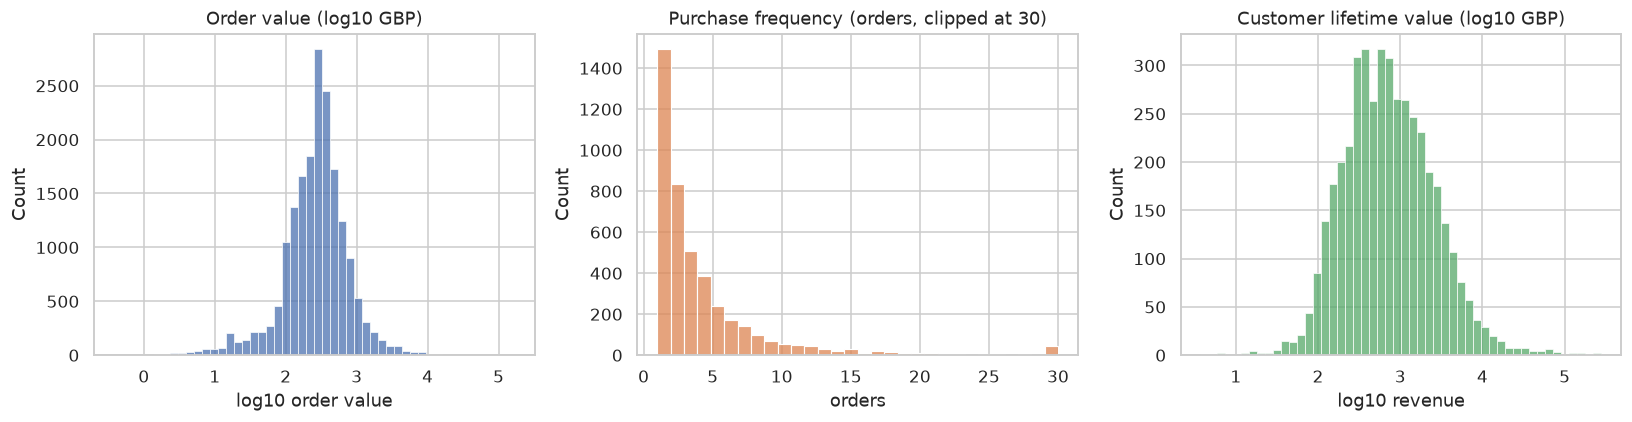

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(np.log10(order_values), bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_title("Order value (log10 GBP)"); axes[0].set_xlabel("log10 order value")
sns.histplot(cust.orders.clip(upper=30), bins=30, ax=axes[1], color="#DD8452")
axes[1].set_title("Purchase frequency (orders, clipped at 30)"); axes[1].set_xlabel("orders")
sns.histplot(np.log10(cust.revenue), bins=50, ax=axes[2], color="#55A868")
axes[2].set_title("Customer lifetime value (log10 GBP)"); axes[2].set_xlabel("log10 revenue")
plt.tight_layout(); plt.show()

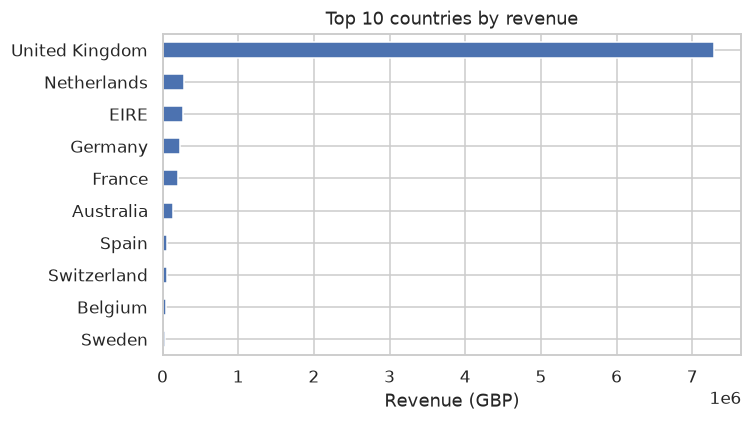

In [8]:
top_countries = df.groupby("Country").TotalPrice.sum().nlargest(10).sort_values()
plt.figure(figsize=(7, 4))
top_countries.plot(kind="barh", color="#4C72B0")
plt.title("Top 10 countries by revenue"); plt.xlabel("Revenue (GBP)"); plt.ylabel("")
plt.tight_layout(); plt.show()

## 4. Feature selection — RFM

Three behavioural features are used for clustering (classic RFM analysis):

| Feature | Definition |
|---|---|
| **Recency** | Days since the customer's last purchase (relative to a snapshot date = last invoice date + 1 day) |
| **Frequency** | Number of distinct invoices (orders) placed |
| **Monetary** | Total amount spent over the period |

These directly describe purchasing behaviour, are available for every customer, and are the standard input for retail segmentation.


In [9]:
snapshot = df.InvoiceDate.max() + pd.Timedelta(days=1)
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
)
print("Snapshot date:", snapshot.date())
print("RFM table shape:", rfm.shape)
rfm.describe()

Snapshot date: 2011-12-10
RFM table shape: (4338, 3)


,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00"
mean,92.54,4.27,"2,048.69"
std,100.01,7.70,"8,985.23"
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,"1,660.60"
max,374.00,209.00,"280,206.02"


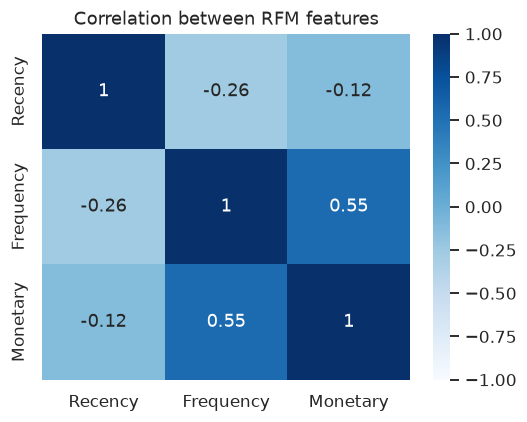

In [10]:
plt.figure(figsize=(5, 4))
sns.heatmap(rfm.corr(), annot=True, cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation between RFM features"); plt.tight_layout(); plt.show()

## 5. Standardisation

R, F and M are heavily right-skewed and on very different scales (days vs counts vs GBP). K-Means uses Euclidean distance, so the features are:
1. **log-transformed** (`log1p`) to compress the long tail, and
2. **standardised** with `StandardScaler` (mean 0, std 1).

Extreme outliers above the 99th percentile of Monetary/Frequency are capped so a handful of wholesale accounts don't dominate the centroids.


In [11]:
rfm_c = rfm.copy()
for col in ["Frequency", "Monetary"]:
    cap = rfm_c[col].quantile(0.99)
    rfm_c[col] = rfm_c[col].clip(upper=cap)

rfm_log = pd.DataFrame({
    "Recency": np.log1p(rfm_c.Recency),
    "Frequency": np.log1p(rfm_c.Frequency),
    "Monetary": np.log1p(rfm_c.Monetary),
}, index=rfm_c.index)

scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)
X_df = pd.DataFrame(X, columns=rfm_log.columns, index=rfm_log.index)
print("Scaled feature means:", np.round(X.mean(axis=0), 6))
print("Scaled feature stds :", np.round(X.std(axis=0), 6))
X_df.head()

Scaled feature means: [-0.  0. -0.]
Scaled feature stds : [1. 1. 1.]


,Recency,Frequency,Monetary
CustomerID,,,
12346,1.46,-0.97,2.70
12347,-2.04,1.11,1.46
12348,0.37,0.40,0.74
12349,-0.62,-0.97,0.73
12350,1.42,-0.97,-0.62


## 6. Choosing K — Elbow method + silhouette score

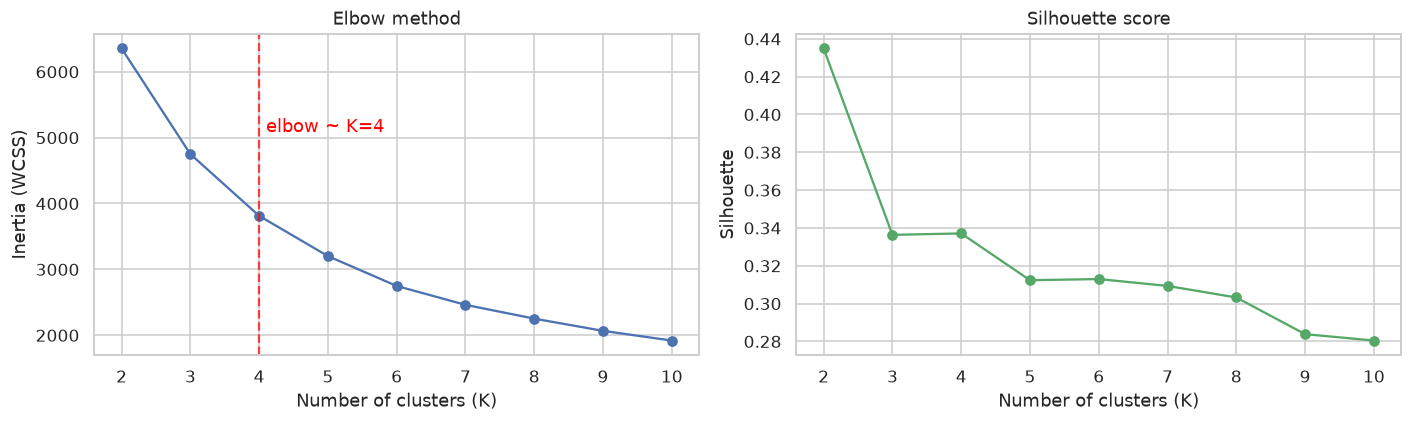

,K,inertia,silhouette
0,2,"6,354.34",0.43
1,3,"4,750.08",0.34
2,4,"3,812.67",0.34
3,5,"3,201.27",0.31
4,6,"2,747.85",0.31
5,7,"2,461.45",0.31
6,8,"2,251.90",0.30
7,9,"2,066.58",0.28
8,10,"1,919.05",0.28


In [12]:
inertia, sil = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, labels))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(K_range), inertia, "o-", color="#4C72B0")
ax[0].set_title("Elbow method"); ax[0].set_xlabel("Number of clusters (K)"); ax[0].set_ylabel("Inertia (WCSS)")
ax[0].axvline(4, ls="--", c="red", alpha=.7); ax[0].annotate("elbow ~ K=4", (4.1, max(inertia)*0.8), color="red")
ax[1].plot(list(K_range), sil, "o-", color="#55A868")
ax[1].set_title("Silhouette score"); ax[1].set_xlabel("Number of clusters (K)"); ax[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

pd.DataFrame({"K": list(K_range), "inertia": inertia, "silhouette": sil})

The inertia curve bends around **K = 4**, and the silhouette score stays high there while giving four business-meaningful groups (rather than 2–3 very coarse ones). **K = 4** is selected.

## 7. Fit K-Means with K = 4

In [13]:
K = 4
kmeans = KMeans(n_clusters=K, init="k-means++", n_init=25, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(X)
X_df["Cluster"] = rfm["Cluster"].values

print("Silhouette score:", round(silhouette_score(X, rfm.Cluster), 3))
print(rfm.Cluster.value_counts().sort_index())
rfm.head()

Silhouette score: 0.337
Cluster
0     737
1    1584
2    1169
3     848
Name: count, dtype: int64


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,"77,183.60",2
12347,2,7,"4,310.00",0
12348,75,4,"1,797.24",2
12349,19,1,"1,757.55",3
12350,310,1,334.40,1


## 8. Cluster visualisation

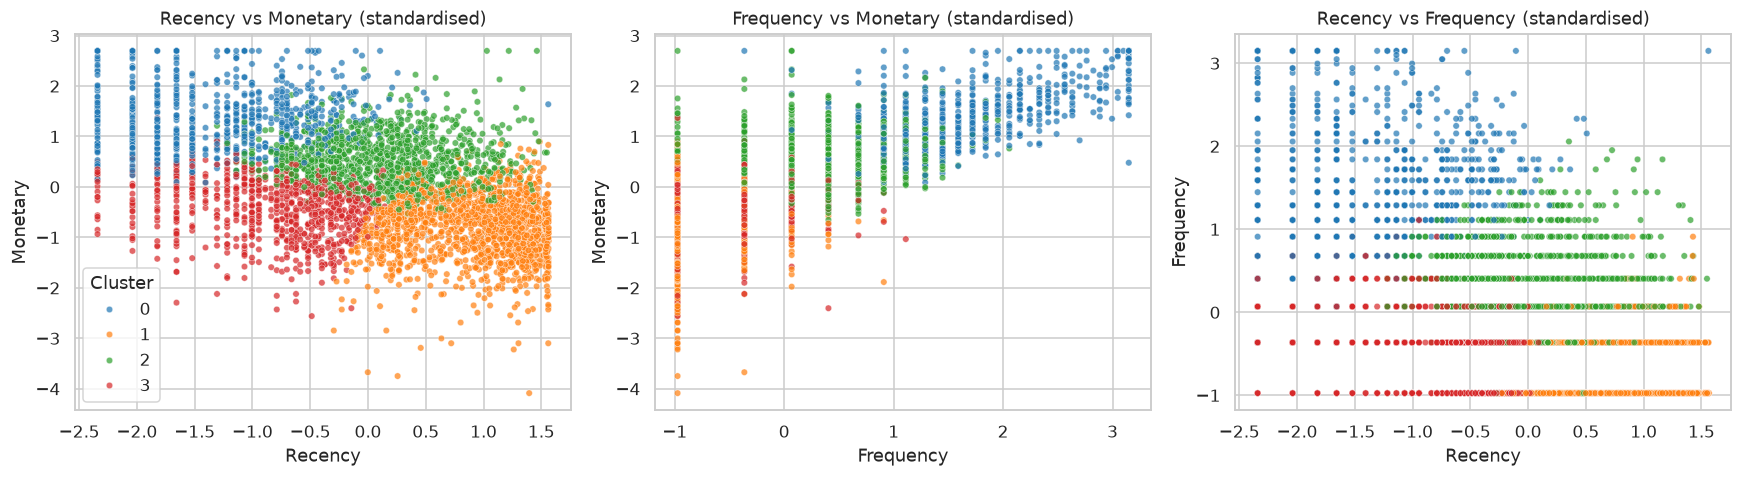

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
pairs = [("Recency", "Monetary"), ("Frequency", "Monetary"), ("Recency", "Frequency")]
for ax, (a, b) in zip(axes, pairs):
    sns.scatterplot(data=X_df, x=a, y=b, hue="Cluster", palette="tab10", s=18, alpha=.7, ax=ax, legend=(ax is axes[0]))
    ax.set_title(f"{a} vs {b} (standardised)")
plt.tight_layout(); plt.show()

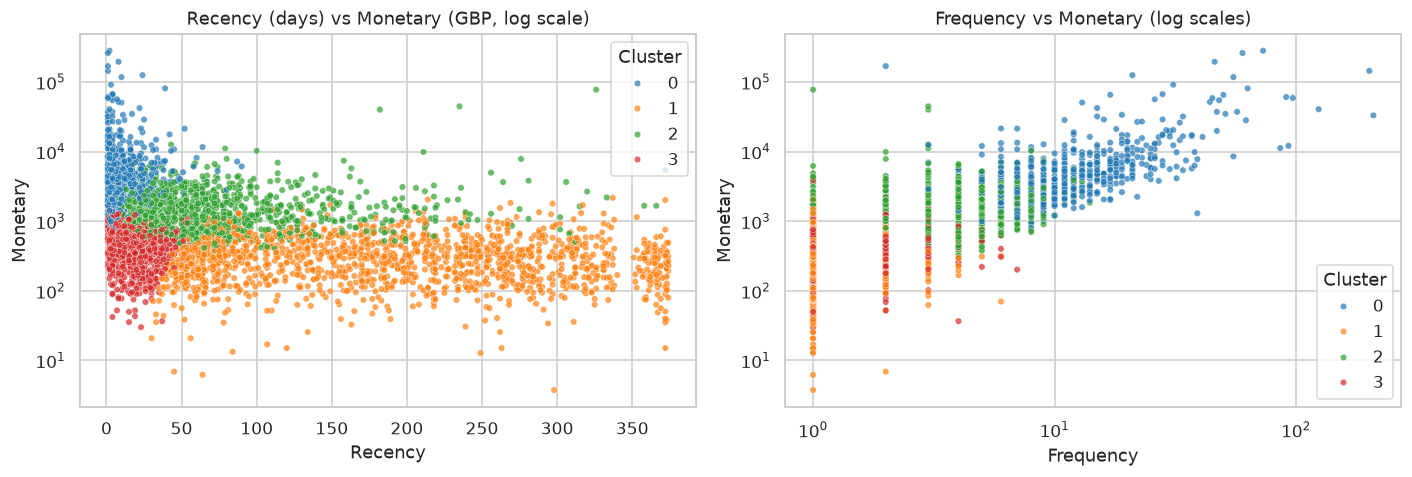

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Cluster", palette="tab10", s=18, alpha=.7, ax=axes[0])
axes[0].set_yscale("log"); axes[0].set_title("Recency (days) vs Monetary (GBP, log scale)")
sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette="tab10", s=18, alpha=.7, ax=axes[1])
axes[1].set_xscale("log"); axes[1].set_yscale("log"); axes[1].set_title("Frequency vs Monetary (log scales)")
plt.tight_layout(); plt.show()

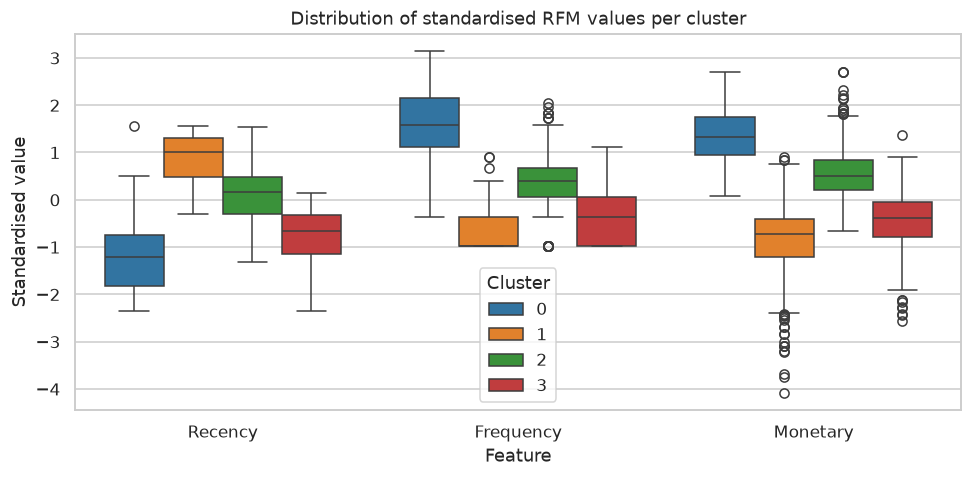

In [16]:
melted = X_df.melt(id_vars="Cluster", var_name="Feature", value_name="Standardised value")
plt.figure(figsize=(9, 4.5))
sns.boxplot(data=melted, x="Feature", y="Standardised value", hue="Cluster", palette="tab10")
plt.title("Distribution of standardised RFM values per cluster")
plt.tight_layout(); plt.show()

## 9. Cluster profiling

In [17]:
profile = rfm.groupby("Cluster").agg(
    Customers=("Recency", "size"),
    Avg_Recency_days=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Median_Monetary=("Monetary", "median"),
    Total_Revenue=("Monetary", "sum"),
)
profile["Share_of_customers_%"] = 100 * profile.Customers / profile.Customers.sum()
profile["Share_of_revenue_%"] = 100 * profile.Total_Revenue / profile.Total_Revenue.sum()
profile["Avg_order_value"] = profile.Avg_Monetary / profile.Avg_Frequency
profile.round(2)

,Customers,Avg_Recency_days,Avg_Frequency,Avg_Monetary,Median_Monetary,Total_Revenue,Share_of_customers_%,Share_of_revenue_%,Avg_order_value
Cluster,,,,,,,,,
0,737,12.15,13.48,"7,888.54","3,649.10","5,813,853.45",16.99,65.42,585.31
1,1584,185.22,1.32,344.64,296.44,"545,913.20",36.51,6.14,261.20
2,1169,70.54,4.09,"1,784.47","1,337.18","2,086,047.73",26.95,23.47,436.69
3,848,19.59,2.04,520.51,450.62,"441,394.51",19.55,4.97,254.85


In [18]:
# Auto-label clusters from their RFM ranks so labels stay correct if the data changes
rank = pd.DataFrame({
    "r": profile.Avg_Recency_days.rank(ascending=True),    # lower recency = better
    "f": profile.Avg_Frequency.rank(ascending=False),
    "m": profile.Avg_Monetary.rank(ascending=False),
})
score = rank.mean(axis=1).sort_values()
names = ["Champions", "Loyal / Potential", "Occasional / Recent", "At-risk / Lapsed"]
labels = {cid: names[i] for i, cid in enumerate(score.index)}
profile["Segment"] = profile.index.map(labels)
rfm["Segment"] = rfm.Cluster.map(labels)
profile[["Segment", "Customers", "Avg_Recency_days", "Avg_Frequency", "Avg_Monetary",
         "Share_of_customers_%", "Share_of_revenue_%"]].round(2)

,Segment,Customers,Avg_Recency_days,Avg_Frequency,Avg_Monetary,Share_of_customers_%,Share_of_revenue_%
Cluster,,,,,,,
0,Champions,737,12.15,13.48,"7,888.54",16.99,65.42
1,At-risk / Lapsed,1584,185.22,1.32,344.64,36.51,6.14
2,Loyal / Potential,1169,70.54,4.09,"1,784.47",26.95,23.47
3,Occasional / Recent,848,19.59,2.04,520.51,19.55,4.97


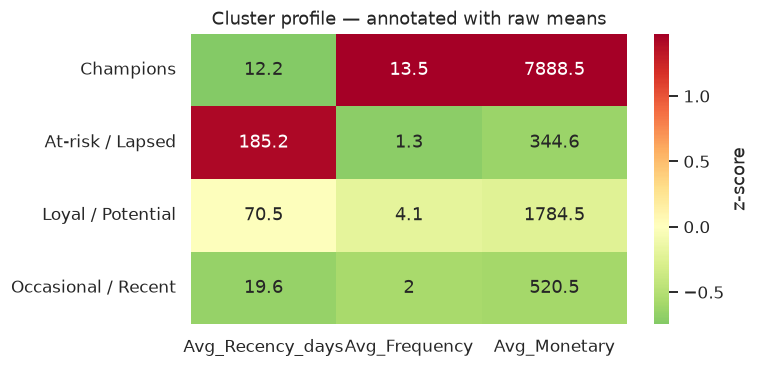

In [19]:
heat = profile[["Avg_Recency_days", "Avg_Frequency", "Avg_Monetary"]].copy()
heat_z = (heat - heat.mean()) / heat.std()
heat_z.index = profile.Segment
plt.figure(figsize=(7, 3.5))
sns.heatmap(heat_z, annot=heat.round(1), fmt="g", cmap="RdYlGn_r", center=0, cbar_kws={"label": "z-score"})
plt.title("Cluster profile — annotated with raw means")
plt.ylabel(""); plt.tight_layout(); plt.show()

## 10. Number of customers per cluster

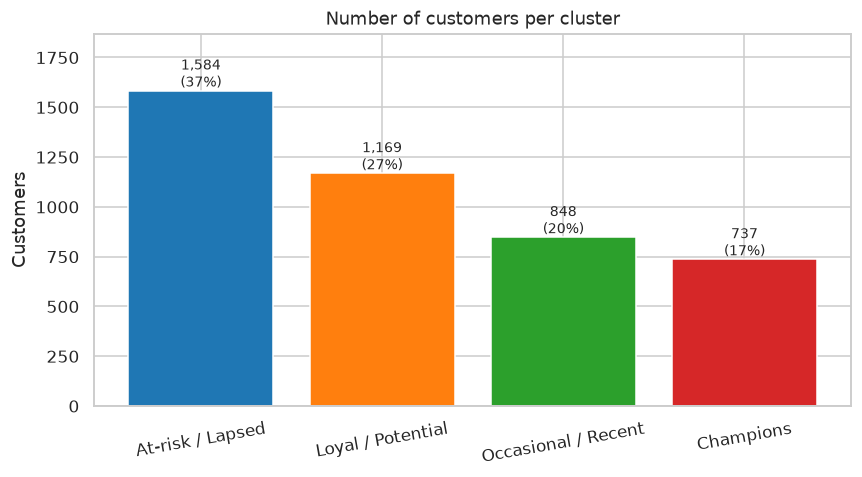

In [20]:
counts = profile.set_index("Segment").Customers.sort_values(ascending=False)
plt.figure(figsize=(8, 4.5))
bars = plt.bar(counts.index, counts.values, color=sns.color_palette("tab10", len(counts)))
for b, v in zip(bars, counts.values):
    plt.text(b.get_x() + b.get_width()/2, v + 20, f"{v:,}\n({v/counts.sum():.0%})", ha="center", fontsize=9)
plt.title("Number of customers per cluster"); plt.ylabel("Customers"); plt.xticks(rotation=10)
plt.ylim(0, counts.max()*1.18)
plt.tight_layout(); plt.show()

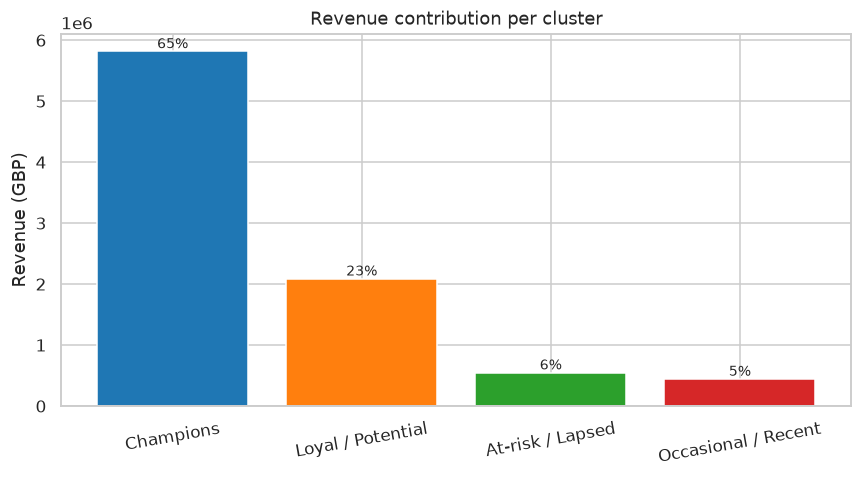

In [21]:
rev = profile.set_index("Segment").Total_Revenue.sort_values(ascending=False)
plt.figure(figsize=(8, 4.5))
bars = plt.bar(rev.index, rev.values, color=sns.color_palette("tab10", len(rev)))
for b, v in zip(bars, rev.values):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v/rev.sum():.0%}", ha="center", va="bottom", fontsize=9)
plt.title("Revenue contribution per cluster"); plt.ylabel("Revenue (GBP)"); plt.xticks(rotation=10)
plt.tight_layout(); plt.show()

In [22]:
summary = profile.set_index("Segment")[["Customers", "Share_of_customers_%", "Share_of_revenue_%",
                                         "Avg_Recency_days", "Avg_Frequency", "Avg_Monetary", "Avg_order_value"]]
summary.round(1)

,Customers,Share_of_customers_%,Share_of_revenue_%,Avg_Recency_days,Avg_Frequency,Avg_Monetary,Avg_order_value
Segment,,,,,,,
Champions,737,17.00,65.40,12.20,13.50,"7,888.50",585.30
At-risk / Lapsed,1584,36.50,6.10,185.20,1.30,344.60,261.20
Loyal / Potential,1169,26.90,23.50,70.50,4.10,"1,784.50",436.70
Occasional / Recent,848,19.50,5.00,19.60,2.00,520.50,254.80


## 11. Insights & recommended marketing actions

Read the table above alongside these segment descriptions (labels are assigned automatically from each cluster's RFM ranking, so they match the numbers printed in this run).

**Champions — best recency, highest frequency and spend**
- Small share of the base but an outsized share of revenue.
- *Actions:* VIP / early-access tier, loyalty points with premium rewards, personal account contact for the top accounts, referral incentives, bundle and cross-sell recommendations based on past baskets. Do **not** discount — these customers already convert at full price.

**Loyal / Potential — recent buyers, good frequency, mid spend**
- The growth engine: they buy regularly but spend less per order than Champions.
- *Actions:* tiered loyalty with a next-tier nudge ("spend X more to unlock"), volume/bundle offers to raise average order value, replenishment reminders, product recommendations from what Champions buy.

**Occasional / Recent — bought recently but only once or twice, low spend**
- Newly acquired or low-engagement customers; highest potential upside if activated.
- *Actions:* onboarding email sequence, second-purchase discount with a short expiry, curated best-seller picks, free-shipping threshold to encourage a bigger basket, review requests to build commitment.

**At-risk / Lapsed — long time since last order, low frequency**
- Largest group by count, smallest by revenue; many are effectively churned.
- *Actions:* win-back campaign ("we miss you" + strong time-limited offer), survey to learn why they stopped, re-target only the ones whose past spend justifies acquisition cost, and suppress the deepest-lapsed from paid re-targeting to protect margin.

**Cross-cutting recommendations**
1. Budget allocation should follow revenue share, not customer count — a small Champions group justifies the largest retention budget per head.
2. Move discount spend away from Champions and towards the second-purchase and win-back moments, where it changes behaviour.
3. Re-score the RFM table monthly; monitor migration between segments (e.g. Loyal → Champions) as the real KPI of the programme.
4. Wholesale-scale accounts were capped at the 99th percentile for clustering; handle them separately with key-account management.

## 12. Export the segmented customer list


In [23]:
out = rfm.reset_index()[["CustomerID", "Recency", "Frequency", "Monetary", "Cluster", "Segment"]]
out.to_csv("customer_segments.csv", index=False)
print("Saved customer_segments.csv —", out.shape)
out.head(10)

Saved customer_segments.csv — (4338, 6)


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,"77,183.60",2,Loyal / Potential
1,12347,2,7,"4,310.00",0,Champions
2,12348,75,4,"1,797.24",2,Loyal / Potential
3,12349,19,1,"1,757.55",3,Occasional / Recent
4,12350,310,1,334.40,1,At-risk / Lapsed
5,12352,36,8,"2,506.04",2,Loyal / Potential
6,12353,204,1,89.00,1,At-risk / Lapsed
7,12354,232,1,"1,079.40",1,At-risk / Lapsed
8,12355,214,1,459.40,1,At-risk / Lapsed
9,12356,23,3,"2,811.43",2,Loyal / Potential
